## Librerías

In [21]:
import pandas as pd
from pathlib import Path
import sys
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

In [22]:
sys.path.append("../src")
from entities import EntityResolver
from graphs import HeterogeneousGraphBuilder
from graphs import GraphFeatureExtractor
from models import NetworkRoleClassifier

In [3]:
# Ignoramos warnings de spaCy para mantener la salida limpia
warnings.filterwarnings("ignore")

## PATHS

In [4]:
BASE_DIR = Path.cwd().parent
CSV_CHATS = BASE_DIR / "data" / "processed" / "chats_completos.csv"
EDGES_CSV_RAW = BASE_DIR / "data" / "processed" / "grafo_aristas.csv"
EDGES_CSV_CLEAN = BASE_DIR / "data" / "processed" / "grafo_aristas_resuelto.csv"
NODES_FEATURES_CSV = BASE_DIR / "data" / "processed" / "nodos_features.csv"

## Orquestación

In [5]:
if not EDGES_CSV_CLEAN.exists():
    print("Iniciando Pipeline de Grafo Heterogéneo...")
    df_chats = pd.read_csv(CSV_CHATS)
    
    # Fase A: Construcción de la Topología Base
    constructor = HeterogeneousGraphBuilder()
    df_grafo_crudo = constructor.build_raw_graph(df_chats)
    df_grafo_crudo.to_csv(EDGES_CSV_RAW, index=False)
    
    # Fase B: Resolución de Entidades (Entity Resolution)
    resolver = EntityResolver()
    df_grafo_limpio = resolver.consolidar_grafo(
        df_grafo=df_grafo_crudo, 
        columnas_entidades=["Origen", "Destino"]
    )
    df_grafo_limpio.to_csv(EDGES_CSV_CLEAN, index=False)
    print("Pipeline completado. Grafo consolidado y guardado.")

else:
    print("Cargando grafo limpio desde caché...")
    df_grafo_limpio = pd.read_csv(EDGES_CSV_CLEAN)

Iniciando Pipeline de Grafo Heterogéneo...
Modelo NLP 'es_core_news_md' cargado correctamente para extracción de entidades.
Analizando dinámicas conversacionales y construyendo aristas...
Pipeline completado. Grafo consolidado y guardado.


In [6]:
# 1. Cargamos el grafo crudo que sacamos en el paso anterior
df_grafo_crudo = pd.read_csv(EDGES_CSV_RAW)

# 2. Instanciamos nuestra clase (podemos inyectarle nuevos alias si descubrimos más)
resolver = EntityResolver()

# 3. Consolidamos la red matemática
df_grafo_limpio = resolver.consolidar_grafo(
    df_grafo=df_grafo_crudo, 
    columnas_entidades=["Origen", "Destino"]
)

### Auditoria

In [7]:
print(f"\nTotal de aristas únicas en la red: {len(df_grafo_limpio)}")

print("\nTop 5 - Relaciones Físicas (COMUNICA_CON):")
display(df_grafo_limpio[df_grafo_limpio['Tipo_Relacion'] == 'COMUNICA_CON'].head(5))

print("\nTop 5 - Relaciones de Influencia (MENCIONA_A):")
display(df_grafo_limpio[df_grafo_limpio['Tipo_Relacion'] == 'MENCIONA_A'].head(5))


Total de aristas únicas en la red: 500

Top 5 - Relaciones Físicas (COMUNICA_CON):


,Origen,Destino,Tipo_Relacion,Peso
0,MIGUEL PALOMERO,RODOLFO REYES,COMUNICA_CON,94
1,RODOLFO REYES,JULIO MARTINEZ SOLA,COMUNICA_CON,86
2,ROBERTO ROSELLI,RODOLFO REYES,COMUNICA_CON,77
3,JULIO MARTINEZ SOLA,RODOLFO REYES,COMUNICA_CON,76
4,RODOLFO REYES,MIGUEL PALOMERO,COMUNICA_CON,68



Top 5 - Relaciones de Influencia (MENCIONA_A):


,Origen,Destino,Tipo_Relacion,Peso
6,JULIO MARTINEZ SOLA,RODOLFO REYES,MENCIONA_A,43
7,RODOLFO REYES,JULIO MARTINEZ SOLA,MENCIONA_A,43
8,ROBERTO ROSELLI,JULIO MARTINEZ SOLA,MENCIONA_A,32
9,ROBERTO ROSELLI,RODOLFO REYES,MENCIONA_A,29
10,ROBERTO ROSELLI,JULIO MARTINEZ MARTINEZ,MENCIONA_A,23


## Creación y cálculo de nodos

In [8]:
# Calculamos las métricas topológicas si no lo hemos hecho antes
if not NODES_FEATURES_CSV.exists():
    extractor = GraphFeatureExtractor()
    df_features = extractor.extract_features(df_grafo_limpio)
    
    # Guardamos nuestro dataset tabular final para Machine Learning
    df_features.to_csv(NODES_FEATURES_CSV, index=False)
    print("Métricas de red calculadas y guardadas con éxito.")
else:
    print("Cargando features de red desde caché...")
    df_features = pd.read_csv(NODES_FEATURES_CSV)

Calculando métricas topológicas (Feature Engineering)...
Métricas de red calculadas y guardadas con éxito.


In [9]:
# Visualizamos a los pesos pesados de la red según el algoritmo PageRank
print("\nTop 10 Nodos más importantes de la red (según PageRank):")
display(df_features.head(10))


Top 10 Nodos más importantes de la red (según PageRank):


,Nodo,In_Degree,Out_Degree,Betweenness,PageRank,Hub_Score,Authority_Score
0,RODOLFO REYES,0.129032,0.370968,0.182137,0.091423,0.181540,2.670273e-01
1,JULIO MARTINEZ SOLA,0.096774,0.306452,0.092791,0.058217,0.206837,1.449610e-01
2,ROBERTO ROSELLI,0.076613,0.346774,0.102684,0.045925,0.226214,7.157828e-02
3,MIGUEL PALOMERO,0.040323,0.100806,0.029826,0.025599,0.174859,6.079536e-02
4,JULIO MARTINEZ MARTINEZ,0.068548,0.072581,0.020692,0.023831,0.018465,6.249591e-02
5,ZAPATERO,0.024194,0.000000,0.000000,0.009980,-0.000000,3.488382e-02
6,SANTIAGO FERNANDEZ LENA,0.020161,0.080645,0.008211,0.007588,0.044848,2.118069e-02
7,FELIPE BACA,0.012097,0.032258,0.015509,0.007294,0.015564,1.389726e-02
8,Y DELOITTE LEGAL,0.004032,0.020161,0.008048,0.007056,0.003423,2.227475e-20
9,RAMON GORDILS,0.012097,0.032258,0.003657,0.005627,0.019294,8.090163e-03


In [10]:
# Visualizamos a los principales Brokers (Highest Betweenness)
print("\nTop 5 Intermediarios/Brokers (según Betweenness Centrality):")
display(df_features.sort_values(by="Betweenness", ascending=False).head(5))


Top 5 Intermediarios/Brokers (según Betweenness Centrality):


,Nodo,In_Degree,Out_Degree,Betweenness,PageRank,Hub_Score,Authority_Score
0,RODOLFO REYES,0.129032,0.370968,0.182137,0.091423,0.181540,0.267027
2,ROBERTO ROSELLI,0.076613,0.346774,0.102684,0.045925,0.226214,0.071578
1,JULIO MARTINEZ SOLA,0.096774,0.306452,0.092791,0.058217,0.206837,0.144961
3,MIGUEL PALOMERO,0.040323,0.100806,0.029826,0.025599,0.174859,0.060795
4,JULIO MARTINEZ MARTINEZ,0.068548,0.072581,0.020692,0.023831,0.018465,0.062496


## Clustering

In [23]:
# Pipeline de Clasificación
clasificador = NetworkRoleClassifier(n_clusters=4)
features = ['In_Degree', 'Out_Degree', 'Betweenness', 'PageRank', 'Hub_Score', 'Authority_Score']

df_model, sil_score, perfil_clusters = clasificador.fit_predict(df_features, features)

print(f"Métrica de Validación (Silhouette Score): {sil_score:.3f}")

Métrica de Validación (Silhouette Score): 0.936


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


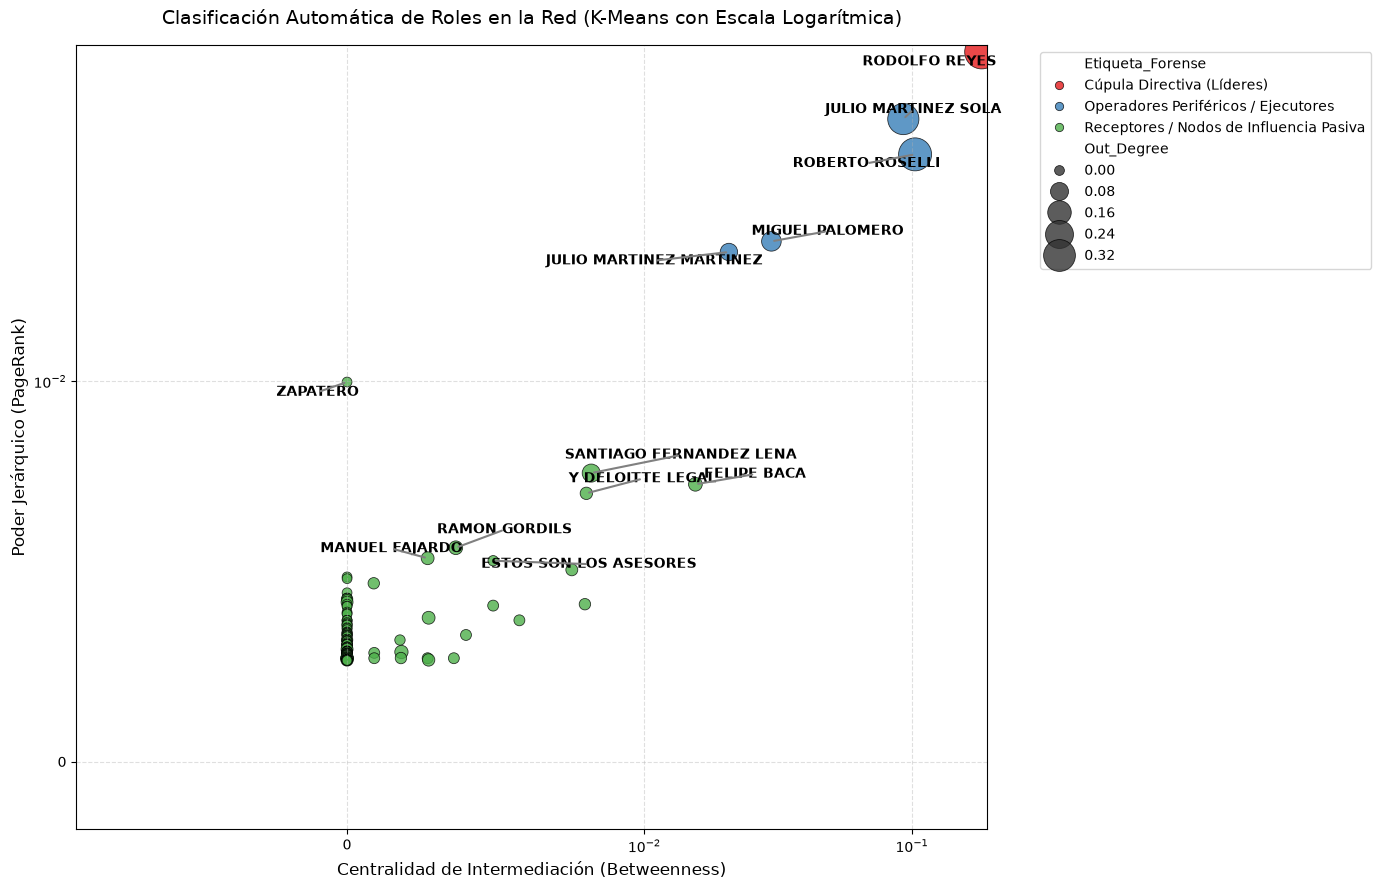

In [24]:
# Visualización Libre de Overplotting
plt.figure(figsize=(14, 9))

# Bubble Chart: El tamaño del punto refleja su actividad saliente (Out_Degree)
sns.scatterplot(
    data=df_model, 
    x='Betweenness', 
    y='PageRank', 
    hue='Etiqueta_Forense', 
    size='Out_Degree',
    sizes=(50, 600),
    palette='Set1', 
    edgecolor='black',
    alpha=0.8
)

# Escala Symlog: Expande los valores cercanos a 0 para separar a los nodos apelotonados
plt.xscale('symlog', linthresh=0.01)
plt.yscale('symlog', linthresh=0.01)

# Listas para el repulsor de textos
textos_a_dibujar = []
# Solo etiquetamos el top 12 global para no ensuciar, asegurando a los protagonistas
top_nodes = df_model.nlargest(12, 'PageRank') 

for _, row in top_nodes.iterrows():
    textos_a_dibujar.append(
        plt.text(row['Betweenness'], row['PageRank'], row['Nodo'], 
                 fontsize=10, fontweight='bold', ha='center', va='center')
    )

# La magia matemática que evita que los textos se sobrepongan
adjust_text(
    textos_a_dibujar, 
    arrowprops=dict(arrowstyle='-', color='gray', lw=1.5),
    expand_points=(1.5, 1.5)
)

plt.title('Clasificación Automática de Roles en la Red (K-Means con Escala Logarítmica)', fontsize=14, pad=15)
plt.xlabel('Centralidad de Intermediación (Betweenness)', fontsize=12)
plt.ylabel('Poder Jerárquico (PageRank)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.tight_layout()
plt.show()